# 04 — Feature Engineering

**Role in pipeline:** Feature pipeline definition layer.

- Loads `telco_cleaned.csv`
- Applies `create_features()` from `features.py` (single source of truth)
- Validates output: nulls, distributions, sanity checks
- Saves `telco_featured.csv`

The same `create_features()` function is imported and called identically in `05_modeling.ipynb`, ensuring zero drift between the feature pipeline definition and the model training pipeline.

In [2]:
import sys
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, ".")
from features import create_features

In [3]:
df_raw = pd.read_csv("../data/processed/telco_cleaned.csv")
print(f"Loaded: {df_raw.shape}")

Loaded: (7021, 20)


In [4]:
df = create_features(df_raw)
print(f"After feature engineering: {df.shape}")
df.head(3)

After feature engineering: (7021, 31)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,tenure_group_24-48,tenure_group_48+,service_count,high_monthly_charges,auto_payment,fiber_customer,long_contract,customer_lifetime_value,avg_monthly_spend,support_dependency
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,...,False,False,1,0,0,0,0,29.85,14.925000,1
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,...,True,False,3,0,0,0,1,1936.30,53.985714,2
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,...,False,False,3,0,0,0,0,107.70,36.050000,2


## Validation

In [5]:
# No nulls should exist in engineered features
engineered = [
    "service_count", "high_monthly_charges", "auto_payment",
    "fiber_customer", "long_contract", "customer_lifetime_value",
    "avg_monthly_spend", "support_dependency"
]
null_counts = df[engineered].isnull().sum()
assert null_counts.sum() == 0, f"Unexpected nulls:\n{null_counts[null_counts > 0]}"
print("Null check passed — all engineered features are complete.")

Null check passed — all engineered features are complete.


In [6]:
# Binary features must only contain 0 and 1
binary_cols = ["high_monthly_charges", "auto_payment", "fiber_customer", "long_contract"]
for col in binary_cols:
    vals = set(df[col].unique())
    assert vals <= {0, 1}, f"{col} has unexpected values: {vals}"
print("Binary feature check passed.")

Binary feature check passed.


In [7]:
# service_count: 0–8, support_dependency: 0–4
assert df["service_count"].between(0, 8).all(), "service_count out of range"
assert df["support_dependency"].between(0, 4).all(), "support_dependency out of range"
print("Range checks passed.")

Range checks passed.


In [8]:
# Churn must be encoded as 0/1
assert set(df["Churn"].unique()) <= {0, 1}, "Churn encoding failed"
print(f"Churn distribution:\n{df['Churn'].value_counts()}")

Churn distribution:
Churn
0    5164
1    1857
Name: count, dtype: int64


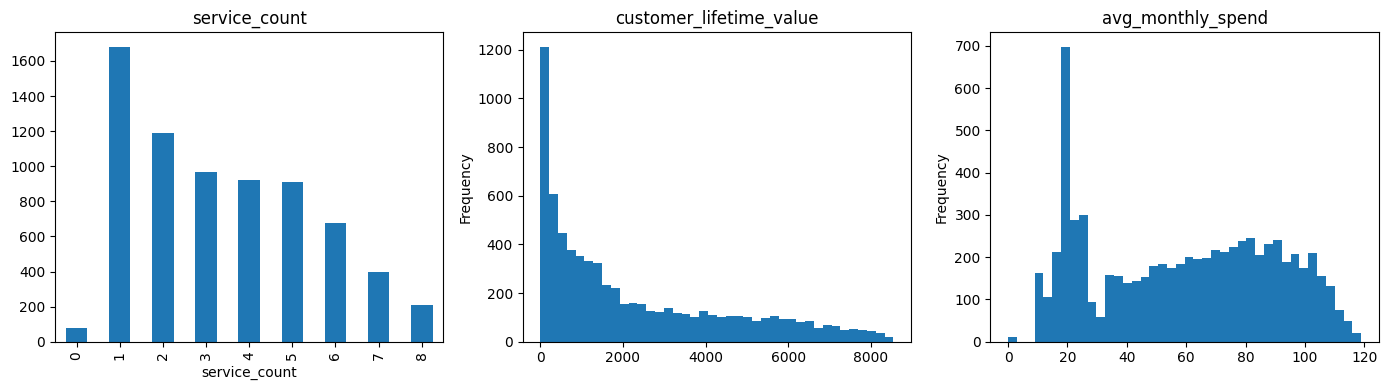

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

df["service_count"].value_counts().sort_index().plot(kind="bar", ax=axes[0], title="service_count")
df["customer_lifetime_value"].plot(kind="hist", bins=40, ax=axes[1], title="customer_lifetime_value")
df["avg_monthly_spend"].plot(kind="hist", bins=40, ax=axes[2], title="avg_monthly_spend")

plt.tight_layout()
plt.show()

In [10]:
df.to_csv("../data/processed/telco_featured.csv", index=False)
print(f"Saved telco_featured.csv: {df.shape}")

Saved telco_featured.csv: (7021, 31)
